[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/daniellopezcano/I-Escola-de-Inverno-do-IFUSP/blob/main/jax-examples/00_caixa_de_ferramentas.ipynb)

# 🟢 Notebook 00 — A Caixa de Ferramentas
### Python, Google Colab e JAX na prática
**I Escola de Inverno do IFUSP — Bloco L01_B02**

> **Modo de uso:** demo guiada pelo instrutor; vocês recebem o notebook depois.
> Objetivo: dominar o ambiente (Colab, GitHub, JAX) e construir uma rede neural
> completamente do zero — camadas, perda, gradiente, treino — sem nenhuma biblioteca
> de ML de alto nível.

---

### 🗺️ Mapa do Curso

| Dia | Bloco | Tema |
|-----|-------|------|
| Ter. 21/07 | L01_B01 | ML e Física: o mapa do território |
| **Ter. 21/07** | **L01_B02 ← você está aqui** | **A caixa de ferramentas** |
| Qua. 22/07 | L02_B01 | Domain shift: teoria |
| Qua. 22/07 | L02_B02 | Mão na massa I — quebrar e consertar um classificador |
| Qui. 23/07 | L03_B01 | Aprendizado contrastivo: teoria |
| Qui. 23/07 | L03_B02 | Mão na massa II — esculpindo embeddings |
| Sex. 24/07 | L04_B01 | Halos de matéria escura com segmentação de instâncias |
| Sex. 24/07 | L04_B02 | J-PAS: domain adaptation com quasares reais |

## 🟢 O que é este ambiente?

**Google Colab** é um serviço gratuito do Google que permite executar código Python
num servidor remoto, direto do navegador — sem instalar nada. O que você vê é um
*notebook Jupyter*: um documento interativo formado por:

- **Células de código** (fundo cinza): contêm código Python executável. Clique e
  pressione `Shift+Enter` para rodar.
- **Células de texto** (como esta): explicações em Markdown. Duplo-clique para editar.

**O kernel** é o processo Python que roda em segundo plano.
Cada célula que você executa mantém o estado: variáveis definidas numa célula
ficam disponíveis nas seguintes.

**GitHub** é o repositório de código onde este notebook vive. Pense nele como
um Google Drive para código — com histórico de versões e colaboração. O botão
"Open in Colab" no topo faz exatamente isso: abre o notebook direto do repositório.

**CPU vs. GPU vs. TPU** (menu *Runtime → Change runtime type*):
- CPU = poucos processadores muito rápidos (médicos especialistas)
- GPU = milhares de processadores simples em paralelo (estagiários fazendo a mesma conta)
- Para álgebra linear de matrizes grandes, a GPU é 10–100× mais rápida.

## 🔵 Setup — importações e configuração global

In [1]:
# Configurações globais — execute esta célula primeiro!
import os
import pickle
import time
import pathlib
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from IPython.display import Image, display

# ── Chave de reprodutibilidade
SEMENTE = 42
CHAVE   = jax.random.PRNGKey(SEMENTE)

# ── Modo PRETRAINED: True  → carrega checkpoints pré-computados (padrão)
#                   False → treina do zero (mais lento; para exploração)
PRETRAINED = True

# ── Caminho dos assets (checkpoints e figuras pré-geradas)
ASSETS = pathlib.Path("assets")

# ── Estilo global dos gráficos
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
})

print(f"JAX versão : {jax.__version__}")
print(f"Dispositivo: {jax.devices()[0]}")
print(f"PRETRAINED : {PRETRAINED}")
print(f"Assets em  : {ASSETS.resolve()}")

JAX versão : 0.10.2
Dispositivo: cpu:0
PRETRAINED : True
Assets em  : /home/dlopez/Documentos/0.profesional/Postdoc/USP/talks_conferences/I-Escola-de-Inverno-do-IFUSP/jax-examples/assets


## 🔵 CPU vs. GPU — vamos medir a diferença

In [2]:
# Multiplicação de matrizes grandes: quanto tempo demora em cada hardware?
TAMANHO = 2000  # matriz 2000 × 2000

# Cria matrizes aleatórias (usando JAX; bloqueia até concluir com .block_until_ready())
A_mat = jax.random.normal(jax.random.PRNGKey(0), (TAMANHO, TAMANHO))
B_mat = jax.random.normal(jax.random.PRNGKey(1), (TAMANHO, TAMANHO))

# Primeiro chamada compila o kernel (JIT) — descartamos esse tempo
_ = (A_mat @ B_mat).block_until_ready()

# Agora medimos
t_ini = time.perf_counter()
C_mat = (A_mat @ B_mat).block_until_ready()
t_fim = time.perf_counter()

dispositivo = jax.devices()[0].device_kind
print(f"Multiplicação de matrizes {TAMANHO}×{TAMANHO}")
print(f"  Dispositivo : {dispositivo}")
print(f"  Tempo       : {(t_fim - t_ini)*1e3:.1f} ms")
print()
print("💡 No Colab com GPU, este mesmo cálculo leva <5 ms — 50–100× mais rápido!")

Multiplicação de matrizes 2000×2000
  Dispositivo : cpu
  Tempo       : 26.7 ms

💡 No Colab com GPU, este mesmo cálculo leva <5 ms — 50–100× mais rápido!


## 🟢 O stack Python científico

Antes de JAX, precisamos entender a base:

- **NumPy** — a *lingua franca* da computação científica em Python.
  Todo array de dados que você manuseia em física computacional é um `numpy.ndarray`.
  Operações vetorizadas (sem laços Python) são a regra de ouro.

- **Matplotlib** — a biblioteca padrão de visualização. Simples, controlável, bonita.

- **JAX** — "NumPy que sabe derivar e roda em GPU."
  Três superpoderes: `jax.numpy` (API idêntica ao NumPy), `jax.grad` (derivadas exatas
  de qualquer código Python), e `jit/vmap` (compilação + vetorização automática).

> *Regra prática: se você sabe NumPy, você já sabe 90% da sintaxe do JAX.*

## 🔵 NumPy — arrays, shapes e broadcasting

In [3]:
# Criação de arrays e operações elementares
posicao = np.array([1.0, 2.0, 3.0])       # vetor de posição (m)
velocidade = np.array([0.5, -1.0, 0.25])   # velocidade (m/s)

print("posicao.shape    :", posicao.shape)
print("posicao.dtype    :", posicao.dtype)
print("posicao + velocidade:", posicao + velocidade)

# Broadcasting: somamos um escalar (temperatura de referência) ao vetor
T_ref  = 273.15
T_data = np.array([20.1, 21.5, 19.8, 22.3])    # medidas em Celsius
T_kelvin = T_data + T_ref                        # broadcasting: escalar + vetor
print("\nTemperaturas (K):", T_kelvin)

# Operações matriciais — matrizes como transformações lineares
M = np.array([[2.0, 0.0],
              [0.0, 0.5]])              # escala x por 2, y por 0.5
vetor = np.array([1.0, 3.0])
print("\nM @ vetor =", M @ vetor)      # produto matriz-vetor

posicao.shape    : (3,)
posicao.dtype    : float64
posicao + velocidade: [1.5  1.   3.25]

Temperaturas (K): [293.25 294.65 292.95 295.45]

M @ vetor = [2.  1.5]


## 🔵 NumPy — fatiamento e indexação

In [4]:
# Simulando um "espectro" com 54 bandas fotométricas (gancho para o J-PAS)
np.random.seed(42)
espectro_jpas = np.random.rand(54)     # 54 bandas entre 0 e 1

print("Espectro completo (54 bandas):", espectro_jpas.shape)
print("Bandas pares (amostragem 2×) :", espectro_jpas[::2].shape)
print("Bandas 10–20                 :", espectro_jpas[10:21].shape)

# Indexação booleana: quais bandas estão acima de 0.8?
bandas_brilhantes = espectro_jpas > 0.8
print(f"\n{bandas_brilhantes.sum()} bandas com fluxo > 0.8")
print("Índices:", np.where(bandas_brilhantes)[0])

# Seleção de múltiplos objetos: 3 estrelas com espectros aleatórios
catalogo = np.random.rand(1000, 54)    # 1000 objetos, 54 bandas
amostra  = catalogo[[0, 42, 99], :]   # seleção por índice
print(f"\nAmostra de 3 objetos: {amostra.shape}")

Espectro completo (54 bandas): (54,)
Bandas pares (amostragem 2×) : (27,)
Bandas 10–20                 : (11,)

11 bandas com fluxo > 0.8
Índices: [ 1  7 11 12 33 34 35 43 50 52 53]

Amostra de 3 objetos: (3, 54)


## 🔵 Matplotlib — um gráfico científico em 1 célula

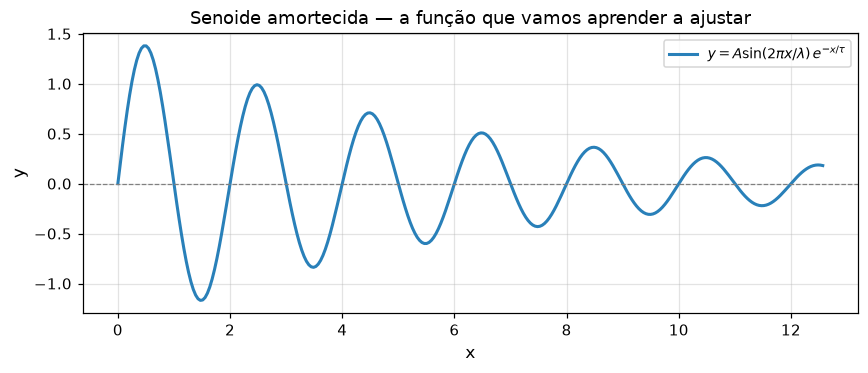

In [5]:
# Plotar uma senoide amortecida (spoiler: esta é a função que vamos ajustar!)
x_plot = np.linspace(0, 4 * np.pi, 300)
y_plot = 1.5 * np.sin(2 * np.pi * x_plot / 2.0) * np.exp(-x_plot / 6.0)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(x_plot, y_plot, lw=2, color="#2980b9", label=r"$y = A\sin(2\pi x/\lambda)\,e^{-x/\tau}$")
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Senoide amortecida — a função que vamos aprender a ajustar", fontsize=12)
ax.legend()
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig(ASSETS / "nb0_fig_senoide_intro.png", dpi=100, bbox_inches="tight")
plt.show()

## 🟢 JAX — NumPy que sabe derivar

O JAX tem três superpoderes que tornam o treino de redes neurais possível:

1. **`jax.numpy`** — API idêntica ao NumPy.
   Você troca `import numpy as np` por `import jax.numpy as jnp` e pronto.

2. **`jax.grad`** — diferenciação automática exata.
   Dado qualquer função Python `f(x)`, `jax.grad(f)` retorna uma nova função
   que calcula a derivada ∂f/∂x em qualquer ponto.
   *Isto é o que torna o treino possível: derivadas exatas de código arbitrário.*

3. **`jax.jit` / `jax.vmap`** — velocidade e vetorização.
   `jit` compila a função para XLA (acelera 10–100×).
   `vmap` paraleliza automaticamente sobre um eixo de batch.

## 🔵 `jax.numpy` — drop-in do NumPy

In [6]:
# A API é idêntica: simplesmente troque 'np' por 'jnp'
x_jax = jnp.linspace(0, 4 * jnp.pi, 300)
y_jax = jnp.sin(x_jax)                     # mesma chamada que em NumPy

print("Tipo JAX :", type(x_jax))            # Array do JAX (roda em GPU)
print("Shape    :", x_jax.shape)
print("Máx. sin :", float(jnp.max(y_jax))) # float() converte para Python scalar

# Broadcasting idêntico ao NumPy
A_mat_jax = jnp.ones((3, 3)) * 2.0
b_vec_jax = jnp.array([1.0, 2.0, 3.0])
print("\nA @ b =", A_mat_jax @ b_vec_jax)

Tipo JAX : <class 'jaxlib._jax.ArrayImpl'>
Shape    : (300,)
Máx. sin : 0.9999861717224121

A @ b = [12. 12. 12.]


## 🔵 `jax.grad` — derivadas exatas de qualquer função Python

In [7]:
# Exemplo 1: derivada de f(x) = x²  →  f'(x) = 2x
def f(x):
    return x ** 2

df_dx = jax.grad(f)               # df_dx é uma função Python!
print(f"f'(3.0) = {df_dx(3.0)}")  # esperamos 2×3 = 6.0
print(f"f'(5.0) = {df_dx(5.0)}")  # esperamos 2×5 = 10.0

# ── Exemplo 2: potencial de Lennard-Jones simplificado ────────────────────────
# V(r) = 4ε[(σ/r)^12 - (σ/r)^6]  — usamos σ=ε=1 para simplificar
def potencial_lj(r):
    """Potencial de Lennard-Jones em unidades reduzidas (σ=ε=1)."""
    return 4.0 * ((1.0 / r) ** 12 - (1.0 / r) ** 6)

# A força é -dV/dr (derivada negativa do potencial)
forca_lj = jax.grad(potencial_lj)

r_vals = jnp.linspace(0.9, 2.5, 6)
print("\nPotencial LJ e força:")
for r in r_vals:
    V = float(potencial_lj(r))
    F = float(forca_lj(r))
    print(f"  r={float(r):.2f}  V={V:+.3f}  F=-dV/dr={-F:+.3f}")

print("\n💡 'jax.grad' calculou derivadas EXATAS de código Python puro.")
print("   É isto que torna o treino de redes neurais possível.")

f'(3.0) = 6.0
f'(5.0) = 10.0

Potencial LJ e força:


  r=0.90  V=+6.636  F=-dV/dr=+138.660
  r=1.22  V=-0.845  F=-dV/dr=-2.347
  r=1.54  V=-0.277  F=-dV/dr=-0.993
  r=1.86  V=-0.094  F=-dV/dr=-0.297
  r=2.18  V=-0.037  F=-dV/dr=-0.101
  r=2.50  V=-0.016  F=-dV/dr=-0.039

💡 'jax.grad' calculou derivadas EXATAS de código Python puro.
   É isto que torna o treino de redes neurais possível.


## 🟣 (Opcional) `jax.jit` e `jax.vmap` — aceleração e batch

> Esta seção é opcional. Execute apenas se tiver tempo ou GPU disponível.

In [8]:
# ── jax.jit: compila a função para XLA (evite em laços de aprendizado pequenos) ──
def somar_quadrados(x):
    return jnp.sum(x ** 2)

somar_jit = jax.jit(somar_quadrados)    # versão compilada

v_grande = jnp.ones(10_000_000)

# Primeiro call: compila (descartamos)
_ = somar_jit(v_grande).block_until_ready()

t0 = time.perf_counter()
r1 = somar_quadrados(v_grande).block_until_ready()
dt_sem_jit = time.perf_counter() - t0

t0 = time.perf_counter()
r2 = somar_jit(v_grande).block_until_ready()
dt_com_jit = time.perf_counter() - t0

print(f"Sem jit : {dt_sem_jit*1e3:.2f} ms")
print(f"Com jit : {dt_com_jit*1e3:.2f} ms")
print(f"Aceleração: {dt_sem_jit/dt_com_jit:.1f}×  (varia por hardware)")

# ── jax.vmap: vetoriza sobre um eixo de batch automaticamente ─────────────────
def distancia_euclidiana(x, y):
    return jnp.sqrt(jnp.sum((x - y) ** 2))

# Versão vetorizada: calcula distâncias para N pares em uma chamada
dist_batch = jax.vmap(distancia_euclidiana, in_axes=(0, 0))

pontos_a = jnp.array([[0.0, 0.0], [1.0, 1.0], [2.0, 3.0]])
pontos_b = jnp.array([[1.0, 1.0], [4.0, 5.0], [2.0, 3.0]])
print("\nDistâncias (vmap):", dist_batch(pontos_a, pontos_b))

Sem jit : 40.77 ms
Com jit : 1.55 ms
Aceleração: 26.2×  (varia por hardware)



Distâncias (vmap): [1.4142135 5.        0.       ]


---
## 🟢 O Exercício Central: Regressão com FCNN do Zero

Vamos construir e treinar uma **rede neural completamente conexa (FCNN)**
sem nenhuma biblioteca de ML — só NumPy/JAX puro.

**A tarefa:** ajustar uma *senoide amortecida* com ruído gaussiano:

$$y = A \sin\!\left(\frac{2\pi x}{\lambda}\right) e^{-x/\tau} + \varepsilon,
   \quad \varepsilon \sim \mathcal{N}(0, \sigma^2)$$

Parâmetros: $A = 1.5$, $\lambda = 2$, $\tau = 6$, $\sigma = 0.15$.

**A arquitetura FCNN:**

- Parâmetros = lista de tuplas `(W, b)` — uma por camada
- `forward(params, x)`: passa o input por todas as camadas
  (`tanh` nas ocultas, linear na saída)
- Camadas: `[1 → 32 → 32 → 1]`

Vamos ver o modelo melhorar passo a passo, época a época.

## 🔵 Gerar os dados

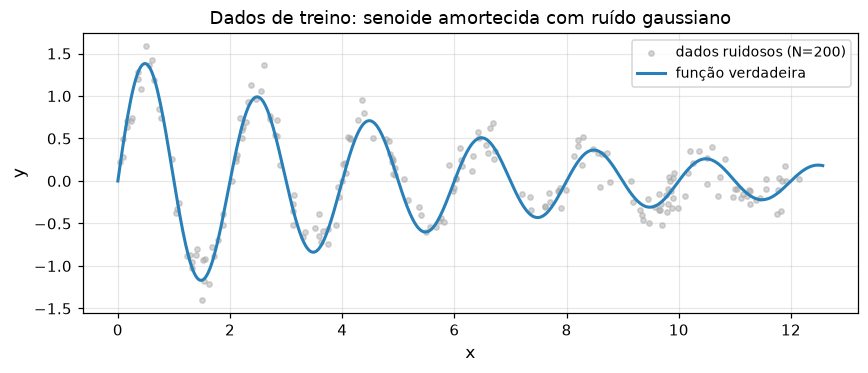

y_ruidoso: [-1.405, 1.590]
Piso do ruído (σ²) = 0.0225


In [9]:
# ── Parâmetros da função alvo ─────────────────────────────────────────────────
N_DADOS  = 200      # número de pontos de treino
A_ALVO   = 1.5      # amplitude
LAM      = 2.0      # comprimento de onda λ
TAU      = 6.0      # constante de decaimento τ
SIGMA_EP = 0.15     # desvio padrão do ruído ε
X_MAX    = 4.0 * np.pi   # domínio: [0, 4π]

# ── Gerar dados com semente fixa ─────────────────────────────────────────────
chave_dados = CHAVE   # mesma chave da célula de setup
chave_dados, k_x, k_ruido = jax.random.split(chave_dados, 3)

x_dados = np.sort(np.array(
    jax.random.uniform(k_x, (N_DADOS,), minval=0.0, maxval=X_MAX)
))

# Função alvo
def funcao_alvo(x):
    return A_ALVO * np.sin(2.0 * np.pi * x / LAM) * np.exp(-x / TAU)

y_verdadeiro = funcao_alvo(x_dados)
ruido        = np.array(jax.random.normal(k_ruido, (N_DADOS,))) * SIGMA_EP
y_ruidoso    = y_verdadeiro + ruido

# ── Normalização do input: x ∈ [0, 4π] → x_norm ∈ [−1, 1] ──────────────────
# Essencial para evitar saturação das ativações tanh na primeira camada.
def normalizar_x(x):
    return 2.0 * x / X_MAX - 1.0

x_norm = normalizar_x(x_dados)

# ── Grid denso para plotar a curva verdadeira ─────────────────────────────────
x_grade      = np.linspace(0.0, X_MAX, 500)
y_grade      = funcao_alvo(x_grade)
x_grade_norm = normalizar_x(x_grade)

# ── Visualizar ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.scatter(x_dados, y_ruidoso, s=12, alpha=0.5, color="#aaaaaa",
           label=f"dados ruidosos (N={N_DADOS})", zorder=2)
ax.plot(x_grade, y_grade, "-", lw=2, color="#2980b9",
        label="função verdadeira", zorder=3)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Dados de treino: senoide amortecida com ruído gaussiano")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"y_ruidoso: [{y_ruidoso.min():.3f}, {y_ruidoso.max():.3f}]")
print(f"Piso do ruído (σ²) = {SIGMA_EP**2:.4f}")

## 🔵 MLP do zero — `init_params` e `forward`

In [10]:
# ── Inicialização dos parâmetros ──────────────────────────────────────────────
def init_params(tamanhos_camadas, chave):
    """
    Inicialização de Glorot (Xavier) para uma rede com camadas tamanhos_camadas.
    Retorna uma lista de tuplas (W, b), uma por par de camadas consecutivas.
    """
    params = []
    for i in range(len(tamanhos_camadas) - 1):
        chave, k_w = jax.random.split(chave)
        entrada  = tamanhos_camadas[i]
        saida    = tamanhos_camadas[i + 1]
        # Inicialização de Glorot: escala proporcional ao tamanho das camadas
        escala = np.sqrt(6.0 / (entrada + saida))
        W = jax.random.uniform(k_w, (entrada, saida),
                               minval=-escala, maxval=escala)
        b = jnp.zeros(saida)
        params.append((W, b))
    return params


# ── Passagem para frente (forward pass) ───────────────────────────────────────
def forward(params, x):
    """
    Propagação forward: ativação tanh nas camadas ocultas, linear na saída.
    x: shape (N, d_entrada) → saída: shape (N, d_saida)
    """
    h = x
    for W, b in params[:-1]:          # camadas ocultas com tanh
        h = jnp.tanh(h @ W + b)
    W, b = params[-1]                 # camada de saída — sem ativação
    return h @ W + b


# ── Testar com a arquitetura [1, 32, 32, 1] ────────────────────────────────────
CAMADAS_NORMAL = [1, 32, 32, 1]
chave_modelo = jax.random.PRNGKey(0)
params_teste  = init_params(CAMADAS_NORMAL, chave_modelo)

# Verificar shapes
print("Parâmetros da rede [1, 32, 32, 1]:")
for i, (W, b) in enumerate(params_teste):
    print(f"  Camada {i}: W={W.shape}, b={b.shape}")

# Teste de forward pass
x_teste = jnp.array(x_norm[:5], dtype=jnp.float32).reshape(-1, 1)
y_teste  = forward(params_teste, x_teste)
print(f"\nForward de 5 amostras → shape {y_teste.shape}")
print(f"Predições iniciais (devem ser pequenas): {y_teste.squeeze()}")

Parâmetros da rede [1, 32, 32, 1]:
  Camada 0: W=(1, 32), b=(32,)
  Camada 1: W=(32, 32), b=(32,)
  Camada 2: W=(32, 1), b=(1,)

Forward de 5 amostras → shape (5, 1)
Predições iniciais (devem ser pequenas): [0.14875033 0.14780942 0.14762689 0.14658888 0.14640984]


## 🔵 Função de perda — MSE

In [11]:
def perda_mse(params, x_batch, y_batch):
    """
    Erro quadrático médio: MSE = média de (ŷᵢ − yᵢ)²
    É esta função que o jax.grad vai diferenciar.
    """
    y_pred = forward(params, x_batch).squeeze(-1)   # shape (N,)
    return jnp.mean((y_pred - y_batch) ** 2)


# ── Verificar que a perda inicial é ≈ variância de y ──────────────────────────
x_in_jax = jnp.array(x_norm, dtype=jnp.float32).reshape(-1, 1)
y_in_jax = jnp.array(y_ruidoso, dtype=jnp.float32)

perda_inicial = float(perda_mse(params_teste, x_in_jax, y_in_jax))
print(f"Perda inicial (modelo aleatório) : {perda_inicial:.4f}")
print(f"Variância de y_ruidoso          : {float(jnp.var(y_in_jax)):.4f}")
print("(Esperado: perda ≈ variância quando o modelo prevê a média)")

Perda inicial (modelo aleatório) : 0.2801
Variância de y_ruidoso          : 0.2881
(Esperado: perda ≈ variância quando o modelo prevê a média)


## 🔵 Loop de treino — descida do gradiente explícita

In [12]:
# ── Configuração ───────────────────────────────────────────────────────────────
N_EPOCAS = 1000           # número de épocas
TAXA_APRENDIZADO = 0.01   # lr — taxa de aprendizado

# ── Laço de treino ou carregamento de checkpoint ───────────────────────────────
if not PRETRAINED:
    # Inicializa o modelo do zero
    chave_treino = jax.random.PRNGKey(0)
    params = init_params(CAMADAS_NORMAL, chave_treino)

    grad_perda = jax.grad(perda_mse)   # função que calcula ∇_params(MSE)

    print(f"Treinando {N_EPOCAS} épocas com SGD explícito "
          f"(lr={TAXA_APRENDIZADO})...")
    print(f"{'Época':>8}  {'Perda':>10}")
    print("-" * 22)

    t_inicio = time.perf_counter()
    for epoca in range(N_EPOCAS + 1):
        # Calcula gradientes
        grads = grad_perda(params, x_in_jax, y_in_jax)

        # Atualização explícita de SGD — sem nenhuma biblioteca de otimização
        params = [
            (W - TAXA_APRENDIZADO * dW, b - TAXA_APRENDIZADO * db)
            for (W, b), (dW, db) in zip(params, grads)
        ]

        if epoca % 100 == 0:
            perda_atual = float(perda_mse(params, x_in_jax, y_in_jax))
            print(f"{epoca:>8}  {perda_atual:>10.6f}")

    t_fim = time.perf_counter()
    print(f"\nTreino concluído em {t_fim - t_inicio:.1f}s")
    print(f"Perda final: {float(perda_mse(params, x_in_jax, y_in_jax)):.6f}")
    print(f"(Piso do ruído = {SIGMA_EP**2:.4f})")

else:
    # Carrega os pesos pré-treinados
    with open(ASSETS / "nb0_fcnn_params.pkl", "rb") as f:
        params = pickle.load(f)
    perda_final = float(perda_mse(params, x_in_jax, y_in_jax))
    print(f"Pesos carregados de  : nb0_fcnn_params.pkl")
    print(f"Perda do modelo      : {perda_final:.6f}")
    print(f"Piso do ruído (σ²)   : {SIGMA_EP**2:.4f}")

Pesos carregados de  : nb0_fcnn_params.pkl
Perda do modelo      : 0.034995
Piso do ruído (σ²)   : 0.0225


## 🔵 Figura-troféu — o modelo aprendendo época a época

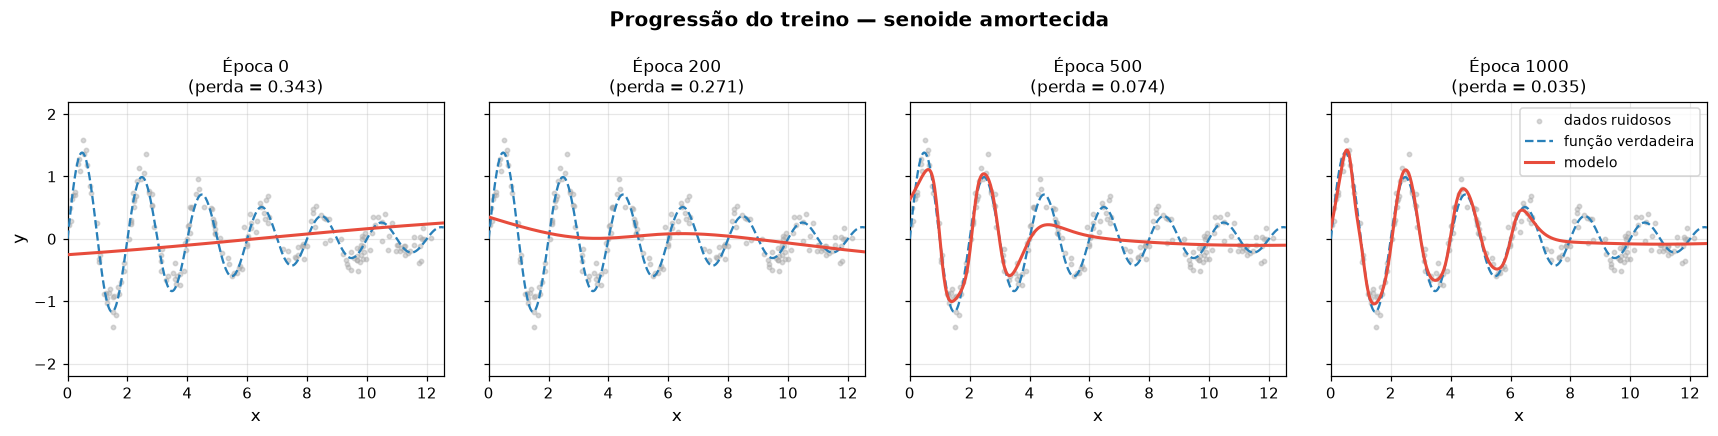

In [13]:
# Carrega os 4 checkpoints e plota a progressão do ajuste
EPOCAS_TROPHY = [0, 200, 500, 1000]
ARQUIVOS_TROPHY = [
    "nb0_epoch0_params.pkl",
    "nb0_epoch200_params.pkl",
    "nb0_epoch500_params.pkl",
    "nb0_fcnn_params.pkl",
]

try:
    fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
    fig.suptitle(
        "Progressão do treino — senoide amortecida",
        fontsize=13, fontweight="bold"
    )

    xg_in = jnp.array(x_grade_norm, dtype=jnp.float32).reshape(-1, 1)

    for ax, epoca, nome_arq in zip(axes, EPOCAS_TROPHY, ARQUIVOS_TROPHY):
        with open(ASSETS / nome_arq, "rb") as f:
            p_ckpt = pickle.load(f)

        y_pred = np.array(forward(p_ckpt, xg_in).squeeze(-1))
        perda  = float(perda_mse(p_ckpt, x_in_jax, y_in_jax))

        ax.scatter(x_dados, y_ruidoso, s=8, alpha=0.45, color="#aaaaaa",
                   label="dados ruidosos", zorder=2)
        ax.plot(x_grade, y_grade, "--", lw=1.5, color="#2980b9",
                label="função verdadeira", zorder=3)
        ax.plot(x_grade, y_pred, "-",  lw=2.0, color="#e74c3c",
                label="modelo", zorder=4)

        ax.set_title(f"Época {epoca}\n(perda = {perda:.3f})", fontsize=11)
        ax.set_xlabel("x")
        if ax is axes[0]:
            ax.set_ylabel("y")
        ax.set_xlim(0, X_MAX)
        ax.set_ylim(-2.2, 2.2)
        ax.grid(True, alpha=0.3)

    axes[-1].legend(loc="upper right", fontsize=9)
    plt.tight_layout()
    plt.show()

except Exception as exc:
    print(f"Renderização ao vivo falhou ({exc}). Exibindo figura pré-computada:")
    display(Image(str(ASSETS / "nb0_fig_trophy.png")))

## 🟡 Pergunta-relâmpago — o que acontece com uma rede maior?

> **Antes de rodar a próxima célula:**
>
> Imagine que trocamos a rede `[1, 32, 32, 1]` por uma rede muito maior,
> `[1, 128, 128, 128, 1]`, e treinamos por **5 000 épocas**.
>
> **O que acontece com o ajuste?**
>
> ✋ *Levante a mão com sua hipótese antes de prosseguir.*
>
> Opções:
> - (A) O ajuste fica muito melhor — mais parâmetros = melhor modelo
> - (B) O ajuste piora — a rede "trava" com gradientes pequenos
> - (C) A rede memoriza os dados ruidosos — ajusta o ruído, não a função

## 🔵 Célula de sobreajuste (*overfitting*)

Modelo pré-treinado carregado.
Perda de treino da rede grande : 0.013914
Perda de treino da rede normal : 0.034995
Piso do ruído (σ²)             : 0.0225

⚠️  A rede grande atingiu perda MENOR que o piso do ruído — ela
   está ajustando o ruído, não a função! Isso é sobreajuste.


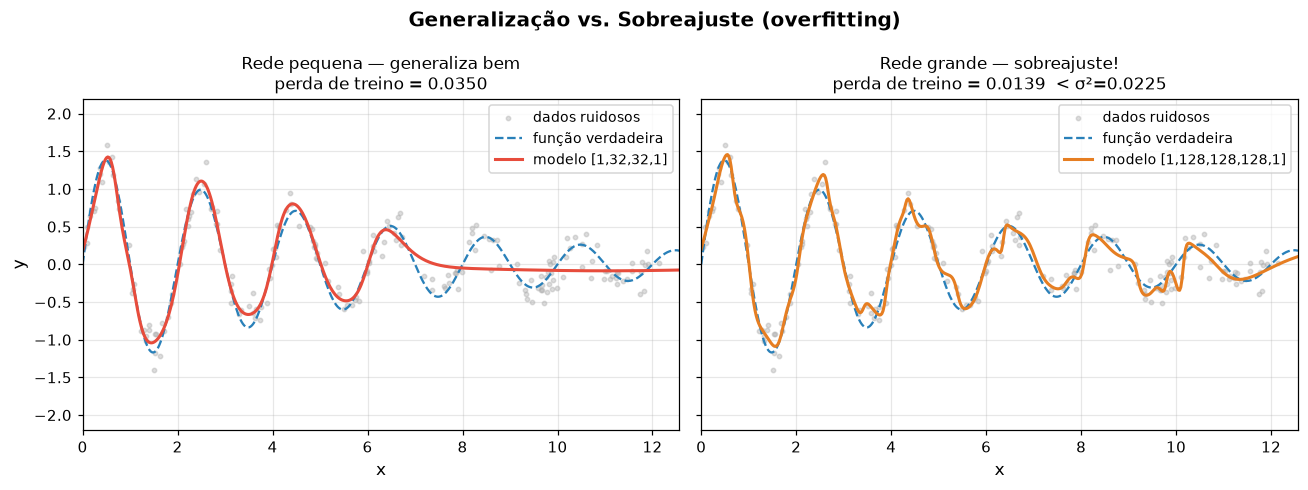


💡 A rede grande memorizou o ruído — não generalizou.
   Na quarta-feira, veremos o que acontece quando a distribuição
   de TESTE é diferente da distribuição de TREINO.


In [14]:
# ── A rede grande: [1, 128, 128, 128, 1] ─────────────────────────────────────
CAMADAS_GRANDE = [1, 128, 128, 128, 1]

if not PRETRAINED:
    # Treino da rede grande (mais lento — pode demorar ~2 min)
    chave_of = jax.random.PRNGKey(1)
    params_overfit = init_params(CAMADAS_GRANDE, chave_of)
    grad_of = jax.grad(perda_mse)

    print(f"Treinando rede grande {CAMADAS_GRANDE} por 5000 épocas...")
    for ep in range(5001):
        g = grad_of(params_overfit, x_in_jax, y_in_jax)
        params_overfit = [
            (W - TAXA_APRENDIZADO * dW, b - TAXA_APRENDIZADO * db)
            for (W, b), (dW, db) in zip(params_overfit, g)
        ]
        if ep % 1000 == 0:
            l = float(perda_mse(params_overfit, x_in_jax, y_in_jax))
            print(f"  época {ep:5d}: perda = {l:.6f}")
else:
    # Carrega o modelo pré-treinado
    with open(ASSETS / "nb0_overfit_params.pkl", "rb") as f:
        params_overfit = pickle.load(f)
    perda_of = float(perda_mse(params_overfit, x_in_jax, y_in_jax))
    print(f"Modelo pré-treinado carregado.")
    print(f"Perda de treino da rede grande : {perda_of:.6f}")
    print(f"Perda de treino da rede normal : {float(perda_mse(params, x_in_jax, y_in_jax)):.6f}")
    print(f"Piso do ruído (σ²)             : {SIGMA_EP**2:.4f}")
    print()
    print("⚠️  A rede grande atingiu perda MENOR que o piso do ruído — ela")
    print("   está ajustando o ruído, não a função! Isso é sobreajuste.")

# ── Comparação visual ─────────────────────────────────────────────────────────
try:
    y_pred_normal = np.array(forward(params, xg_in).squeeze(-1))
    y_pred_of     = np.array(forward(params_overfit, xg_in).squeeze(-1))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
    fig.suptitle("Generalização vs. Sobreajuste (overfitting)",
                 fontsize=13, fontweight="bold")

    # ─ Rede normal ─
    ax1.scatter(x_dados, y_ruidoso, s=8, alpha=0.4, color="#aaaaaa",
                label="dados ruidosos")
    ax1.plot(x_grade, y_grade, "--", lw=1.5, color="#2980b9",
             label="função verdadeira")
    ax1.plot(x_grade, y_pred_normal, "-", lw=2, color="#e74c3c",
             label="modelo [1,32,32,1]")
    ax1.set_title("Rede pequena — generaliza bem\n"
                  f"perda de treino = "
                  f"{float(perda_mse(params, x_in_jax, y_in_jax)):.4f}",
                  fontsize=11)
    ax1.set_xlabel("x"); ax1.set_ylabel("y")
    ax1.set_xlim(0, X_MAX); ax1.set_ylim(-2.2, 2.2)
    ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

    # ─ Rede grande (sobreajuste) ─
    ax2.scatter(x_dados, y_ruidoso, s=8, alpha=0.4, color="#aaaaaa",
                label="dados ruidosos")
    ax2.plot(x_grade, y_grade, "--", lw=1.5, color="#2980b9",
             label="função verdadeira")
    ax2.plot(x_grade, y_pred_of, "-", lw=2, color="#e67e22",
             label="modelo [1,128,128,128,1]")
    ax2.set_title("Rede grande — sobreajuste!\n"
                  f"perda de treino = "
                  f"{float(perda_mse(params_overfit, x_in_jax, y_in_jax)):.4f}"
                  f"  < σ²={SIGMA_EP**2:.4f}",
                  fontsize=11)
    ax2.set_xlabel("x")
    ax2.set_xlim(0, X_MAX)
    ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\n💡 A rede grande memorizou o ruído — não generalizou.")
    print("   Na quarta-feira, veremos o que acontece quando a distribuição")
    print("   de TESTE é diferente da distribuição de TREINO.")

except Exception as exc:
    print(f"Renderização falhou ({exc}). Exibindo figura pré-computada:")
    display(Image(str(ASSETS / "nb0_fig_overfit.png")))

## 🟢 Mapa de vocabulário

| O que fizemos | Jargão padrão | Significado |
|---------------|---------------|-------------|
| Função alvo ruidosa | **tarefa** (task) | O que queremos que a rede aprenda |
| Ruído ε | **distribuição dos dados** | Variabilidade inerente das observações |
| `init_params` + `forward` | **modelo** | A função parametrizada que queremos ajustar |
| `forward(params, x)` | **inferência** | Aplicar o modelo a novos dados |
| `perda_mse(params, x, y)` | **função de perda** | Mede o quão errado o modelo está |
| `jax.grad(perda_mse)` | **gradiente** | Direção de subida mais íngreme da perda |
| `params - lr × grad` | **descida do gradiente** | Passo em direção ao mínimo da perda |
| Repetição desse passo | **época** | Uma iteração completa pelo conjunto de dados |
| Modelo que acerta nos dados de treino | **generalização** | O objetivo real do treino |
| Modelo que acerta o ruído de treino | **sobreajuste** (overfitting) | O que queremos evitar |
| `PRETRAINED = True` | **checkpoint** | Pesos salvos de um treino anterior |

> **Takeaway:** *Treinar uma rede = descer o gradiente de uma função de perda.*
> Todo o resto — arquiteturas, regularização, otimizadores — é engenharia em volta disso.

## 🟣 (Opcional) Exploração: ativação, largura e taxa de aprendizado

> Esta seção é opcional. Execute em casa ou se houver tempo.
> Mude `PRETRAINED = False` na célula de setup para ver o treino ao vivo.

In [15]:
# ── (a) Trocar tanh por ReLU ─────────────────────────────────────────────────
def forward_relu(params, x):
    """Igual ao forward, mas com ReLU nas camadas ocultas."""
    h = x
    for W, b in params[:-1]:
        h = jax.nn.relu(h @ W + b)   # ReLU em vez de tanh
    W, b = params[-1]
    return h @ W + b


# ── (b) Variar a largura da rede ─────────────────────────────────────────────
# Experimento: treine redes [1, N, N, 1] para N ∈ {4, 16, 64} e compare perdas
if not PRETRAINED:
    larguras = [4, 16, 64]
    print("Largura | Perda final (200 épocas, SGD lr=0.01)")
    print("-" * 45)
    for N in larguras:
        p_exp = init_params([1, N, N, 1], jax.random.PRNGKey(0))
        g_fn  = jax.grad(perda_mse)
        for _ in range(200):
            g  = g_fn(p_exp, x_in_jax, y_in_jax)
            p_exp = [(W - 0.01 * dW, b - 0.01 * db)
                     for (W, b), (dW, db) in zip(p_exp, g)]
        l = float(perda_mse(p_exp, x_in_jax, y_in_jax))
        print(f"  N={N:3d}  | {l:.5f}")
else:
    print("(Defina PRETRAINED = False para executar este experimento)")

(Defina PRETRAINED = False para executar este experimento)


## 🟡 Para casa

Experimentos para fazer no seu próprio tempo:

1. **Ajustar outra função:** substitua a senoide amortecida por uma função de sua
   escolha (ex.: $|sin(x)|$, $x^3 e^{-x}$, uma curva de luz de exoplaneta).
   Precisou mudar a arquitetura ou a taxa de aprendizado?

2. **Diagnóstico de sobreajuste:** divida os 200 pontos em 160 de treino e 40 de
   validação. Plote a perda de treino **e** de validação ao longo das épocas.
   Identifique o ponto de overfitting (onde a validação começa a subir enquanto
   o treino continua a cair).

3. **(🟣 Desafio)** Implemente **SGD com momentum**:
   ```
   velocidade = 0.9 × velocidade + gradiente
   params     = params − lr × velocidade
   ```
   Compare a curva de perda com o SGD puro. Convergiu mais rápido?